In [ ]:
# NOTHING OS — Notebook Styling
from IPython.display import HTML, display

display(HTML('''
<style>
  @import url('https://fonts.googleapis.com/css2?family=Share+Tech+Mono&family=Space+Mono&display=swap');

  :root {
    --nothing-black:   #0A0A0A;
    --nothing-surface: #111111;
    --nothing-border:  #2A2A2A;
    --nothing-white:   #F5F5F5;
    --nothing-gray-1:  #CCCCCC;
    --nothing-gray-2:  #888888;
    --nothing-gray-3:  #555555;
    --nothing-red:     #FF1C1C;
    --font-ndot:       'Share Tech Mono', monospace;
    --font-body:       'Space Mono', monospace;
  }

  body, .jp-Notebook {
    background: var(--nothing-black) !important;
    font-family: var(--font-body) !important;
  }

  .jp-Cell { border-radius: 0 !important; }

  .jp-InputArea-editor, .jp-CodeCell .jp-Editor {
    background: var(--nothing-surface) !important;
    border: 1px solid var(--nothing-border) !important;
    border-radius: 0 !important;
    font-family: var(--font-body) !important;
    font-size: 12px !important;
  }

  .jp-OutputArea-output {
    background: #0D0D0D !important;
    border-left: 2px solid var(--nothing-border) !important;
    font-family: var(--font-body) !important;
    color: var(--nothing-gray-1) !important;
    font-size: 12px !important;
  }

  .jp-MarkdownOutput h1, .jp-MarkdownOutput h2, .jp-MarkdownOutput h3 {
    font-family: var(--font-ndot) !important;
    color: var(--nothing-white) !important;
    letter-spacing: 0.1em;
    text-transform: uppercase;
    border-bottom: 1px solid var(--nothing-border) !important;
    padding-bottom: 8px;
  }

  .jp-MarkdownOutput h1 { font-size: 22px !important; }
  .jp-MarkdownOutput h2 { font-size: 16px !important; }
  .jp-MarkdownOutput h3 { font-size: 13px !important; color: var(--nothing-gray-2) !important; }

  .jp-MarkdownOutput p, .jp-MarkdownOutput li {
    color: var(--nothing-gray-2) !important;
    font-family: var(--font-body) !important;
    font-size: 12px !important;
  }

  .jp-MarkdownOutput code {
    background: var(--nothing-surface) !important;
    color: var(--nothing-red) !important;
    border: 1px solid var(--nothing-border) !important;
    border-radius: 0 !important;
    padding: 1px 5px;
    font-size: 11px !important;
  }

  .jp-Toolbar {
    background: #070707 !important;
    border-bottom: 1px solid var(--nothing-border) !important;
  }
</style>
'''))

# And configure matplotlib globally:
import matplotlib as mpl
mpl.rcParams.update({
    'figure.facecolor': '#0A0A0A', 'axes.facecolor': '#111111',
    'axes.edgecolor': '#2A2A2A', 'axes.labelcolor': '#888888',
    'text.color': '#888888', 'xtick.color': '#555555', 'ytick.color': '#555555',
    'grid.color': '#2A2A2A', 'grid.linewidth': 0.5, 'grid.linestyle': ':',
    'axes.grid': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'monospace', 'figure.titlesize': 11,
    'legend.facecolor': '#111111', 'legend.edgecolor': '#2A2A2A',
    'lines.linewidth': 1.5, 'axes.titlesize': 10, 'axes.labelsize': 9,
    'axes.titlecolor': '#F5F5F5',
})

NOTHING_RED    = '#FF1C1C'
NOTHING_WHITE  = '#F5F5F5'
NOTHING_GRAY   = '#888888'
NOTHING_DIM    = '#555555'
NOTHING_MUTED  = '#3A3A3A'


# M5 Forecasting - Baseline Models (ARIMA & Naive)

This notebook evaluates baseline models for the top 200 items in the M5 dataset.

**Models:**
- Last Value
- Seasonal Naive (weekly)
- Moving Average (28 days)
- ARIMA (1, 1, 1)

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append(os.path.abspath('../'))
from src.data.loader import M5Loader
from src.models.baseline import ARIMABaseline, NaiveBaselines, calculate_metrics

# Settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading & Preparation

In [2]:
loader = M5Loader(data_dir='../data')
calendar, sales, prices = loader.load_all()

# Select top 200 items by total volume
d_cols = [c for c in sales.columns if c.startswith('d_')]
sales['total_sales'] = sales[d_cols].sum(axis=1)
top_200 = sales.sort_values('total_sales', ascending=False).head(200)
top_200 = top_200.drop(columns=['total_sales'])

# Melt to long format
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_long = top_200.melt(id_vars=id_cols, var_name='d', value_name='sales')

# Map 'd' to actual dates from calendar
d_to_date = dict(zip(calendar['d'], pd.to_datetime(calendar['date'])))
df_long['date'] = df_long['d'].map(d_to_date)
df_long = df_long.sort_values(['id', 'date']).reset_index(drop=True)

print(f"Data shape for top 200 items: {df_long.shape}")

INFO:src.data.loader:Loading all M5 datasets...
INFO:src.data.loader:Loading calendar data...
INFO:src.data.loader:Loading sales data...
INFO:src.data.loader:Loading prices data...


Data shape for top 200 items: (388200, 9)


## 2. Train / Test Split (90/10)

In [14]:
dates = df_long['date'].unique()
dates = np.sort(dates)
split_idx = int(len(dates) * 0.9)
train_date_end = dates[split_idx]

df_train = df_long[df_long['date'] <= train_date_end]
df_test = df_long[df_long['date'] > train_date_end]

print(f"Training dates: {dates[0]} to {train_date_end}")
print(f"Test dates: {dates[split_idx+1]} to {dates[-1]}")

horizons = [1, 7, 14, 28]
max_h = max(horizons)
# We will extract the exact target days for the horizons
# Horizon 1 = day 1 of test, Horizon 7 = day 7 of test, etc.
test_dates = df_test['date'].unique()
test_dates = np.sort(test_dates)
target_dates = {h: test_dates[h-1] for h in horizons if h-1 < len(test_dates)}

actuals_df = []
for h, d in target_dates.items():
    subset = df_test[df_test['date'] == d][['id', 'sales']].copy()
    subset['horizon'] = h
    actuals_df.append(subset)

actuals = pd.concat(actuals_df)

Training dates: 2011-01-29T00:00:00.000000000 to 2015-11-10T00:00:00.000000000
Test dates: 2015-11-11T00:00:00.000000000 to 2016-05-22T00:00:00.000000000


## 3. Fit Baseline Models

In [15]:
print("Fitting Naive Baselines...")
naive = NaiveBaselines(seasonal_period=7, ma_window=28)
naive.fit(df_train, id_col='id', time_col='date', target_col='sales')
naive_preds = naive.predict(horizons=horizons)

print("Fitting ARIMA(1,1,1)...")
arima = ARIMABaseline(order=(1, 1, 1))
arima.fit(df_train, id_col='id', time_col='date', target_col='sales')
arima_preds = arima.predict(horizons=horizons)

# Merge predictions with actuals
results = actuals.merge(naive_preds, on=['id', 'horizon'])
results = results.merge(arima_preds, on=['id', 'horizon'])

Fitting Naive Baselines...
Fitting ARIMA(1,1,1)...


## 4. Evaluation


--- Evaluation Metrics ---


,Horizon,Model,MAE,RMSE,WMAPE
0,1,last_value,8.405000,14.789016,0.441555
1,1,seasonal_naive,8.865000,15.506934,0.465721
2,1,moving_average,8.071607,13.261461,0.424040
3,1,arima_forecast,12.077722,16.511979,0.634501
4,7,last_value,7.640000,13.835823,0.477799
5,7,seasonal_naive,7.640000,13.835823,0.477799
6,7,moving_average,8.520893,12.736026,0.532889
7,7,arima_forecast,12.857811,17.307343,0.804116
8,14,last_value,9.010000,14.975981,0.437804
9,14,seasonal_naive,9.010000,14.975981,0.437804



Saved baseline WMAPE to logs/eda/baseline_wmape_benchmark.csv


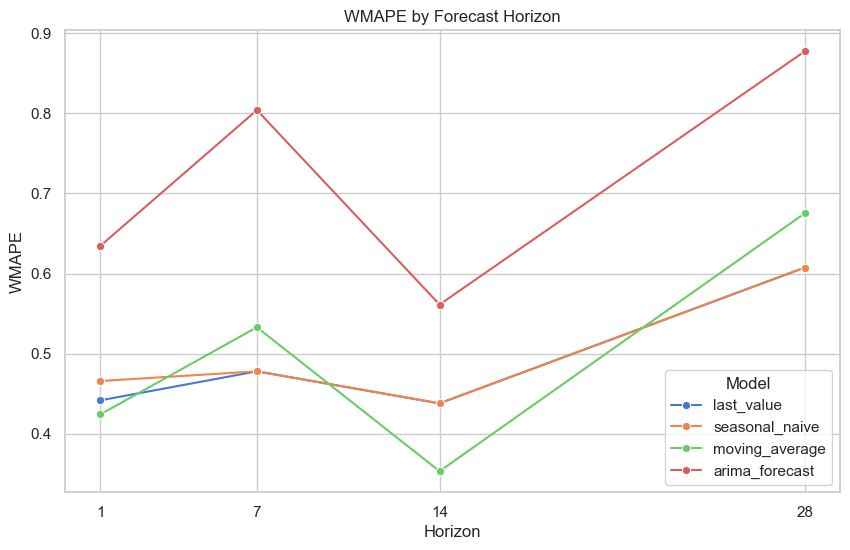

In [16]:
metrics_list = []
models = ['last_value', 'seasonal_naive', 'moving_average', 'arima_forecast']

for h in horizons:
    h_res = results[results['horizon'] == h]
    for m in models:
        mae, rmse, wmape = calculate_metrics(h_res['sales'].values, h_res[m].values)
        metrics_list.append({
            'Horizon': h,
            'Model': m,
            'MAE': mae,
            'RMSE': rmse,
            'WMAPE': wmape
        })

metrics_df = pd.DataFrame(metrics_list)
print("\n--- Evaluation Metrics ---")
display(metrics_df)

# Save WMAPE benchmark
wmape_pivot = metrics_df.pivot(index='Horizon', columns='Model', values='WMAPE')
wmape_pivot.to_csv('../logs/eda/baseline_wmape_benchmark.csv')
print("\nSaved baseline WMAPE to logs/eda/baseline_wmape_benchmark.csv")

plt.figure(figsize=(10, 6))
sns.lineplot(data=metrics_df, x='Horizon', y='WMAPE', hue='Model', marker='o')
plt.title('WMAPE by Forecast Horizon')
plt.xticks(horizons)
plt.show()

## 5. Forecast vs Actual Plot

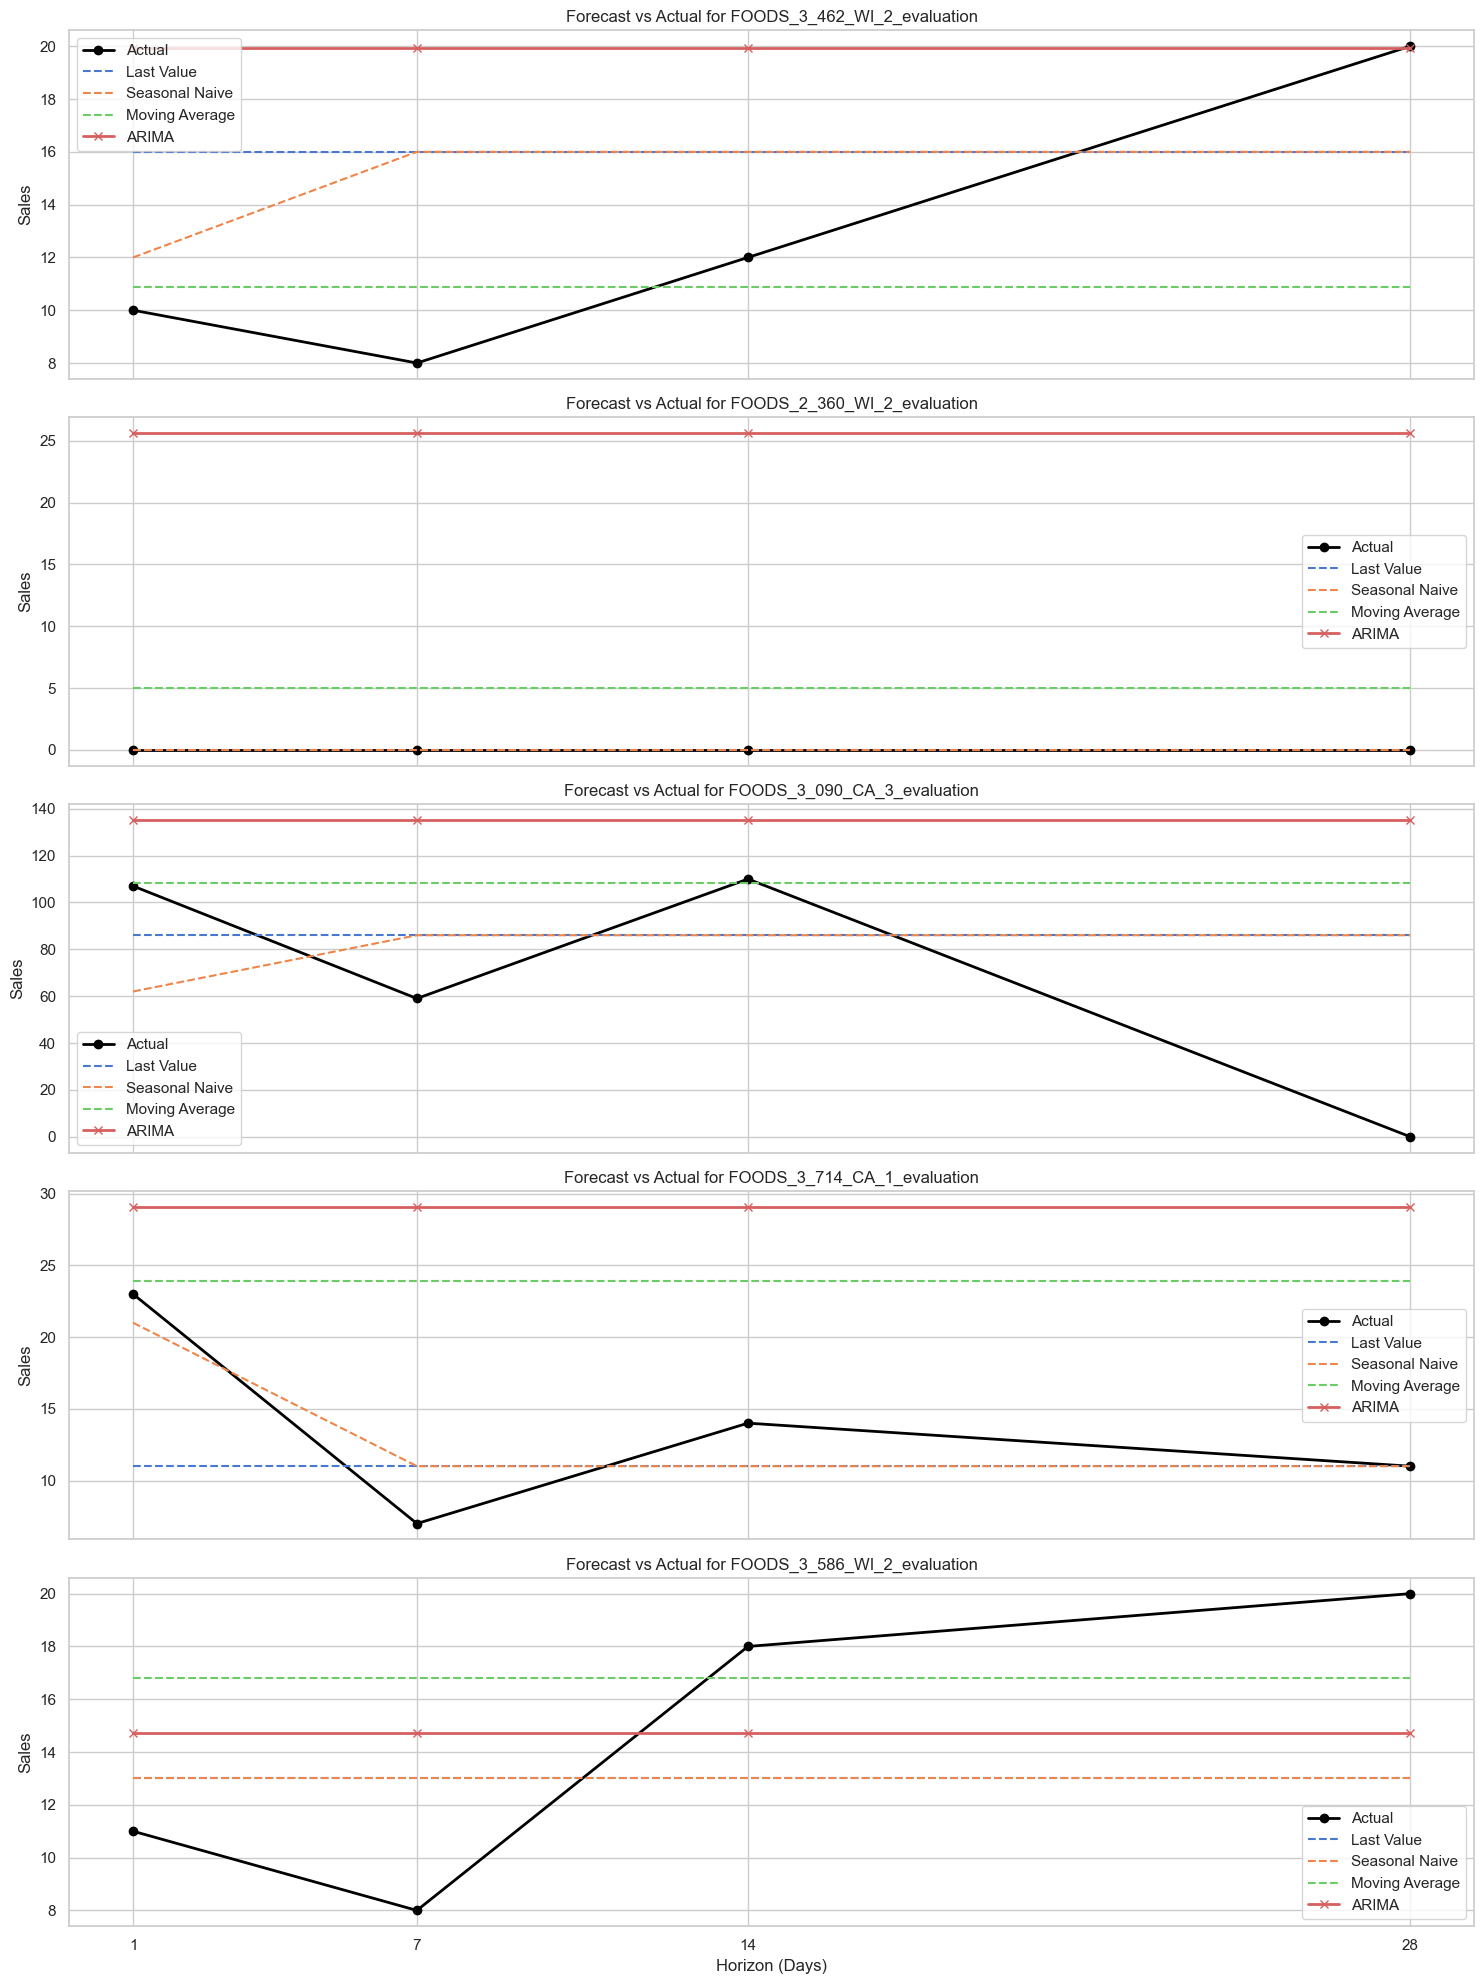

In [17]:
sample_items = results['id'].drop_duplicates().sample(5, random_state=42)

fig, axes = plt.subplots(5, 1, figsize=(15, 20), sharex=True)
axes = axes.flatten()

for i, item in enumerate(sample_items):
    item_res = results[results['id'] == item].sort_values('horizon')
    
    axes[i].plot(item_res['horizon'], item_res['sales'], label='Actual', marker='o', linewidth=2, color='black')
    axes[i].plot(item_res['horizon'], item_res['last_value'], label='Last Value', linestyle='--')
    axes[i].plot(item_res['horizon'], item_res['seasonal_naive'], label='Seasonal Naive', linestyle='--')
    axes[i].plot(item_res['horizon'], item_res['moving_average'], label='Moving Average', linestyle='--')
    axes[i].plot(item_res['horizon'], item_res['arima_forecast'], label='ARIMA', marker='x', linewidth=2)
    
    axes[i].set_title(f"Forecast vs Actual for {item}")
    axes[i].set_ylabel('Sales')
    axes[i].legend()
    axes[i].set_xticks(horizons)

axes[-1].set_xlabel('Horizon (Days)')
plt.tight_layout()
plt.show()